In [3]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("../DataSets/Fleet Data.csv")

In [5]:
df

,Parent Airline,Airline,Aircraft Type,Current,Future,Historic,Total,Orders,Unit Cost,Total Cost (Current),Average Age
0,Aegean Airlines,Aegean Airlines,Airbus A319,1.0,NaN,3.0,4.0,NaN,$90,$90,11.6
1,Aegean Airlines,Olympic Air,Airbus A319,NaN,NaN,8.0,8.0,NaN,$90,$0,NaN
2,Aegean Airlines,Aegean Airlines,Airbus A320,38.0,NaN,3.0,41.0,NaN,$98,"$3,724",7.5
3,Aegean Airlines,Olympic Air,Airbus A320,NaN,NaN,9.0,9.0,NaN,$98,$0,NaN
4,Aegean Airlines,Aegean Airlines,Airbus A321,8.0,NaN,NaN,8.0,NaN,$115,$919,10.3
...,...,...,...,...,...,...,...,...,...,...,...
1578,WestJet,WestJet,Boeing 757,NaN,NaN,1.0,1.0,NaN,$73,$0,NaN
1579,WestJet,WestJet,Boeing 767,4.0,NaN,NaN,4.0,NaN,$187,$748,24.5
1580,WestJet,WestJet Encore,De Havilland Canada DHC-8 Dash 8,33.0,NaN,NaN,33.0,9.0,$31,"$1,033",2.0
1581,Wizz Air,Wizz Air,Airbus A320,63.0,NaN,9.0,72.0,8.0,$98,"$6,174",5.1


#### We checked the dataset for missing values, incorrect data types, and outliers. Missing values were filled or removed as needed. Columns with currency values were cleaned and converted into a standard numeric format to allow accurate analysis

In [7]:
df.columns = df.columns.str.replace(' ', '')

In [8]:
df.columns=df.columns.str.replace(' ','_',regex=True).astype('object')

In [9]:
df.UnitCost=df.UnitCost.replace("[$,.]"," ",regex=True).astype("float64")

In [10]:
df.UnitCost.unique()

array([ 90.,  98., 115.,  22.,  74.,  14.,  31.,  75., 240., 312.,  28.,
       316., 187., 295., 265.,  45.,  82., 145., 175.,  16.,   7.,  nan,
       216.,  73.,  46.,   6.,  18.,  20.,   4.,  72.,  32.,  39.,  41.,
        30.,  68.,   8.,  29.,  66., 308., 433.,  49., 190.,  47.,  37.,
        25.,   3.,  12.,  96., 126., 320.,  11.,  33.,  50.,  56.,   2.,
        19.])

In [11]:
df.columns = df.columns.str.replace(r'\(Current\)', '', regex=True)

In [12]:
df.TotalCost=df.TotalCost.replace("[$,]","",regex=True).astype("float64")

In [13]:
df.dtypes

ParentAirline     object
Airline           object
AircraftType      object
Current          float64
Future           float64
Historic         float64
Total            float64
Orders           float64
UnitCost         float64
TotalCost        float64
AverageAge       float64
dtype: object

In [14]:
df.isnull().sum()

ParentAirline       0
Airline             0
AircraftType        0
Current           724
Future           1395
Historic          470
Total              99
Orders           1235
UnitCost           35
TotalCost          27
AverageAge        763
dtype: int64

In [15]:
df.describe()

,Current,Future,Historic,Total,Orders,UnitCost,TotalCost,AverageAge
count,859.000000,188.000000,1113.000000,1484.000000,348.000000,1548.000000,1556.000000,820.000000
mean,24.033760,3.382979,14.513028,24.955526,26.419540,117.808786,1496.897815,10.115000
std,41.091234,4.656331,23.763373,46.651526,43.024179,97.340875,3493.654109,6.859362
min,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.100000
25%,5.000000,1.000000,3.000000,4.000000,5.000000,45.000000,0.000000,5.000000
50%,12.000000,2.000000,7.000000,11.000000,13.500000,75.000000,142.000000,8.900000
75%,26.500000,4.000000,16.000000,27.000000,28.250000,187.000000,1568.000000,14.500000
max,718.000000,38.000000,325.000000,952.000000,400.000000,433.000000,53118.000000,39.000000


In [16]:
df.TotalCost=df.TotalCost.fillna(1496.89)

In [17]:
df.Current=df.Current.fillna(24.033)

In [18]:
df.Future=df.Future.fillna(3.38)

In [19]:
df.Future=df.Future.fillna(3.38)

In [20]:
df.Historic=df.Historic.fillna(14.51)

In [21]:
df.Total=df.Total.fillna(24.95)

In [22]:
df.Orders=df.Orders.fillna(24.41)

In [23]:
df.UnitCost=df.UnitCost.fillna(117.80)

In [24]:
df.AverageAge=df.AverageAge.fillna(10.11)

In [25]:
df.AircraftType.value_counts()

AircraftType
Boeing 737                       147
Airbus A320                      135
Airbus A330                       86
Boeing 767                        83
Airbus A321                       79
                                ... 
Hawker Beechcraft Hawker 4000      1
Canadair CRJ-200 Series            1
Bombardier Q400 Nextgen            1
Canadair CRJ-200                   1
Mil Mi-8T                          1
Name: count, Length: 101, dtype: int64

# 1.Descriptive Analysis

## Aircraft Type Distribution Across Parent Airlines

#### Certain parent airlines dominate with large, diverse fleets, while others focus on fewer aircraft types. Aircraft types like the A320 or B737 are common across multiple airlines, indicating standardization preferences.

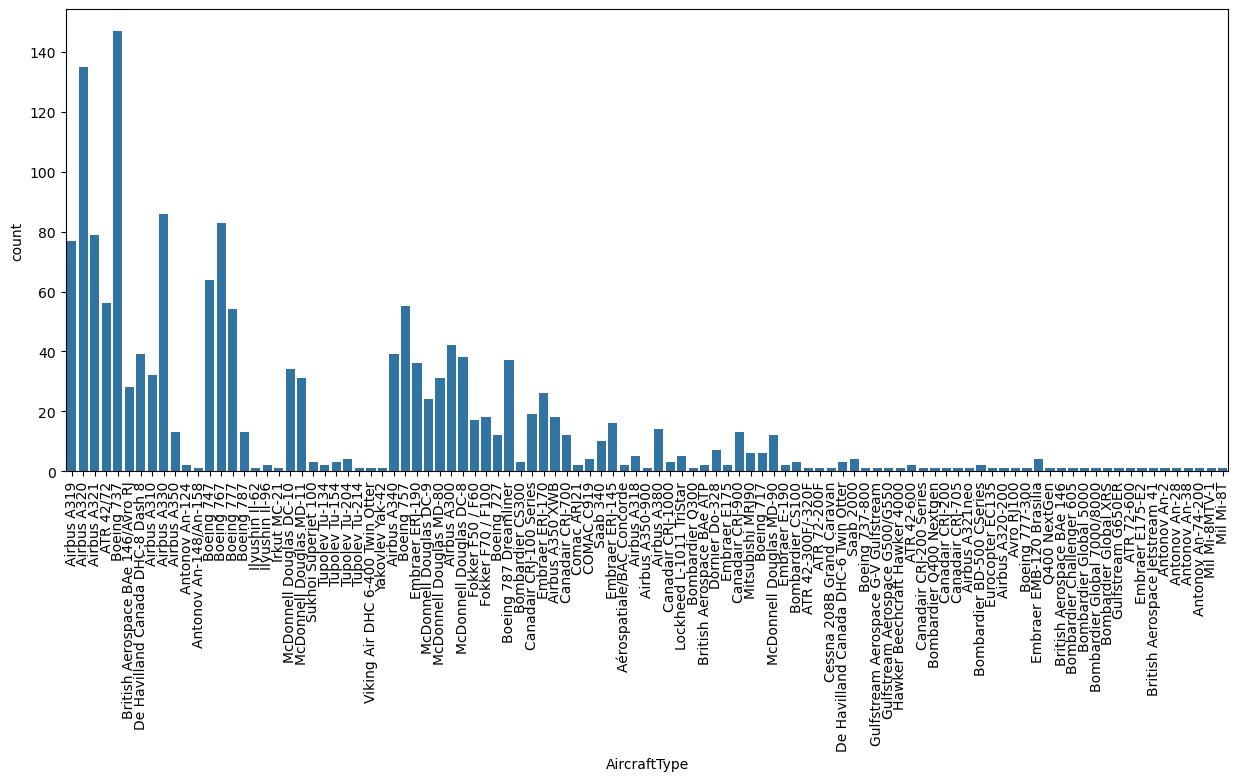

In [29]:
plt.figure(figsize=(15,6))
sb.countplot(x=df.AircraftType)
plt.xticks(rotation=90)
plt.show()
sb.set_palette("coolwarm")

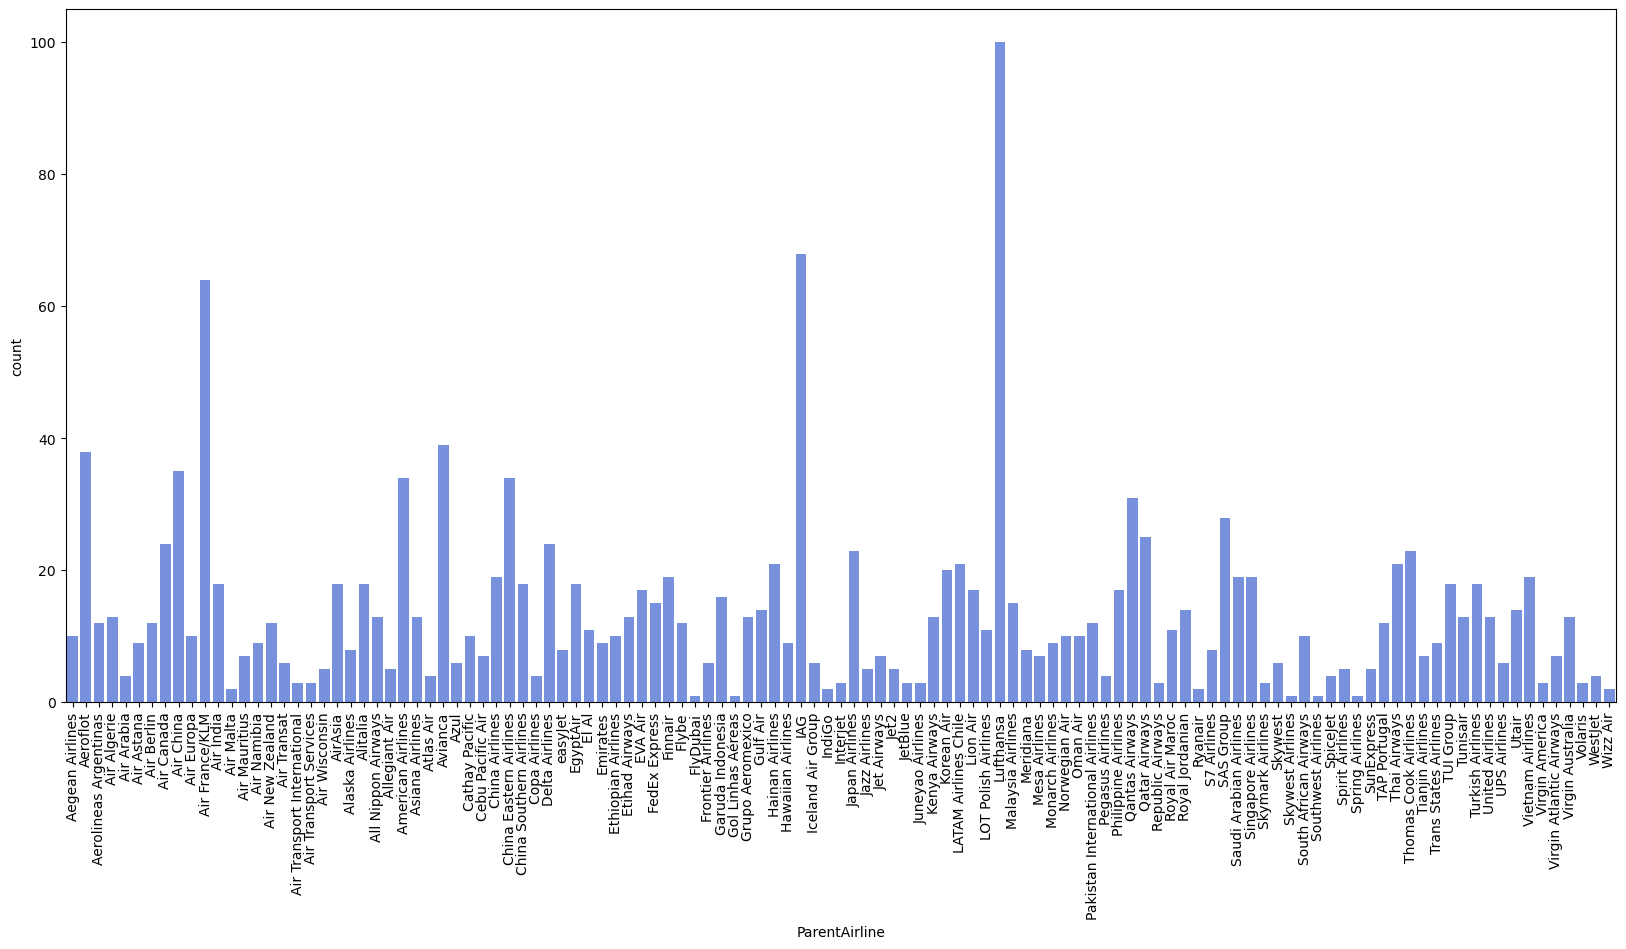

In [30]:
plt.figure(figsize=(20,9))
sb.countplot(x=df.ParentAirline)
plt.xticks(rotation=90)
plt.show()
sb.set_palette("coolwarm")

## Fleet Status by Airline: Current, Future, Historic

#### Different airlines are at different growth stages—some are expanding with many future orders, while others are maintaining or shrinking their fleets.

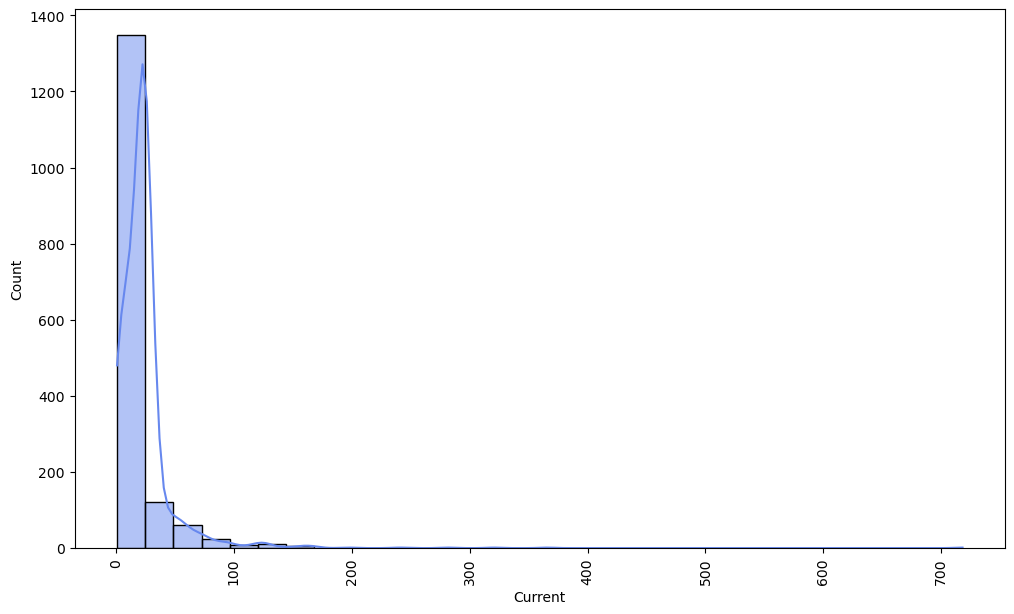

In [33]:
plt.figure(figsize=(12,7))
sb.histplot(x=df.Current,bins=30,kde=True)
plt.xticks(rotation=90)
plt.show()
sb.set_palette("coolwarm")

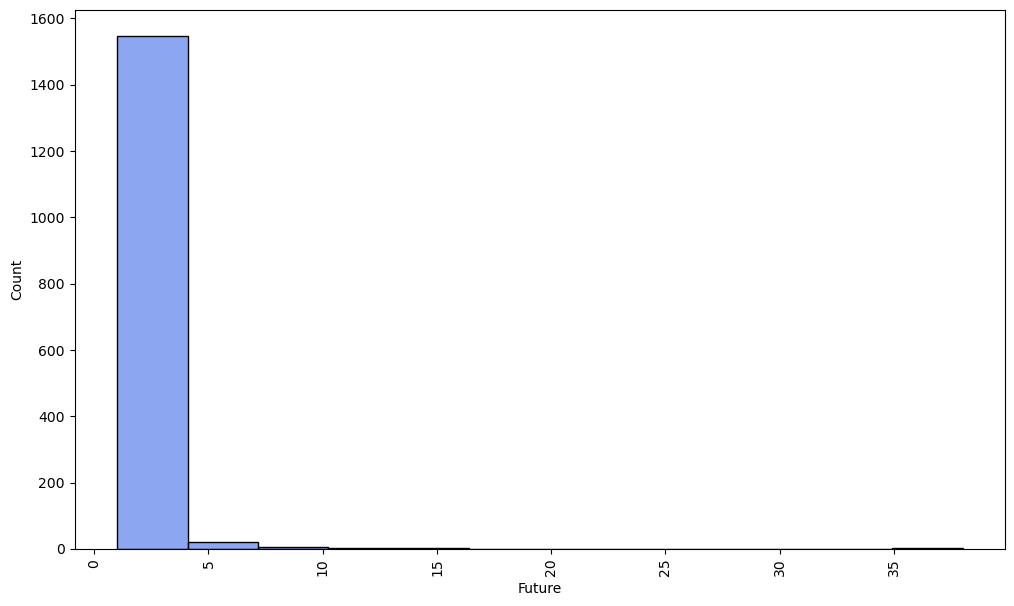

In [35]:
plt.figure(figsize=(12,7))
sb.histplot(x=df.Future)
plt.xticks(rotation=90)
plt.show()
sb.set_palette("coolwarm")

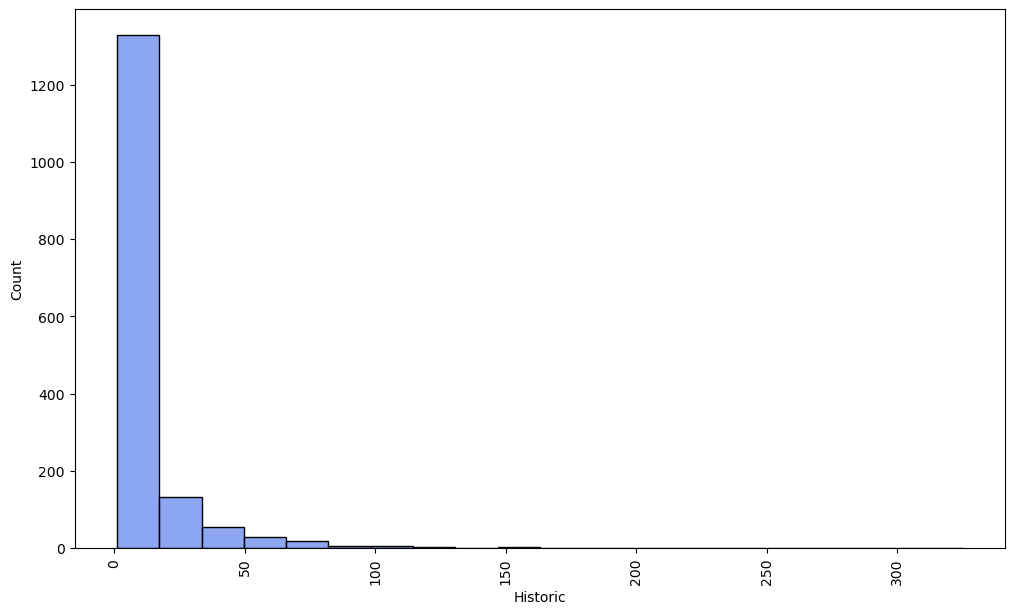

In [228]:
plt.figure(figsize=(12,7))
sb.histplot(x=df.Historic ,bins=20)
plt.xticks(rotation=90)
plt.show
sb.set_palette("coolwarm")

In [59]:
pd.crosstab(df['ParentAirline'], df['AircraftType'])

AircraftType,ATR 42-300F/-320F,ATR 42-600,ATR 42/72,ATR 72-200F,ATR 72-600,Airbus A300,Airbus A310,Airbus A318,Airbus A319,Airbus A320,...,Q400 NextGen,Saab 2000,Saab 340,Sukhoi Superjet 100,Tupolev Tu-134,Tupolev Tu-154,Tupolev Tu-204,Tupolev Tu-214,Viking Air DHC 6-400 Twin Otter,Yakovlev Yak-42
ParentAirline,,,,,,,,,,,,,,,,,,,,,
Aegean Airlines,0,0,2,0,0,0,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0
Aeroflot,0,0,0,0,0,0,1,0,3,2,...,0,0,0,2,1,1,2,1,1,1
Aerolineas Argentinas,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Air Algerie,0,0,1,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Air Arabia,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Virgin Australia,0,0,2,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
Volaris,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
WestJet,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Statistical Summary of Unit Cost, Average Age, and Orders

#### Unit costs vary a lot between aircraft types. Some airlines invest in newer planes (lower average age), while others operate older fleets. Orders show how aggressively airlines are planning for the future.

In [63]:
print(df.ParentAirline.unique())
p=input('Enter Parent Airline')
a=df[df.ParentAirline==p]
a

['Aegean Airlines' 'Aeroflot' 'Aerolineas Argentinas' 'Air Algerie'
 'Air Arabia' 'Air Astana' 'Air Berlin' 'Air Canada' 'Air China'
 'Air Europa' 'Air France/KLM' 'Air India' 'Air Malta' 'Air Mauritius'
 'Air Namibia' 'Air New Zealand' 'Air Transat'
 'Air Transport International' 'Air Transport Services' 'Air Wisconsin'
 'AirAsia' 'Alaska Airlines' 'Alitalia' 'All Nippon Airways'
 'Allegiant Air' 'American Airlines' 'Asiana Airlines' 'Atlas Air'
 'Avianca' 'Azul' 'Cathay Pacific' 'Cebu Pacific Air' 'China Airlines'
 'China Eastern Airlines' 'China Southern Airlines' 'Copa Airlines'
 'Delta Airlines' 'easyJet' 'EgyptAir' 'El Al' 'Emirates'
 'Ethiopian Airlines' 'Etihad Airways' 'EVA Air' 'FedEx Express' 'Finnair'
 'Flybe' 'FlyDubai' 'Frontier Airlines' 'Garuda Indonesia'
 'Gol Linhas Aéreas' 'Grupo Aeromexico' 'Gulf Air' 'Hainan Airlines'
 'Hawaiian Airlines' 'IAG' 'Iceland Air Group' 'IndiGo' 'Interjet'
 'Japan Airlines' 'Jazz Airlines' 'Jet Airways' 'Jet2' 'JetBlue'
 'Juneyao Airline

Enter Parent Airline Volaris


,ParentAirline,Airline,AircraftType,Current,Future,Historic,Total,Orders,UnitCost,TotalCost,AverageAge
1574,Volaris,Volaris,Airbus A319,15.0,3.38,9.00,24.0,24.41,90.0,1344.0,9.7
1575,Volaris,Volaris,Airbus A320,44.0,3.00,1.00,48.0,42.00,98.0,4312.0,3.3
1576,Volaris,Volaris,Airbus A321,9.0,1.00,14.51,10.0,24.41,115.0,1034.0,0.6


# 2.Visualization

## Aircraft Models Distribution by Airline

#### Each airline tends to focus on specific aircraft types. This shows their route strategy—e.g., regional vs. long-haul.

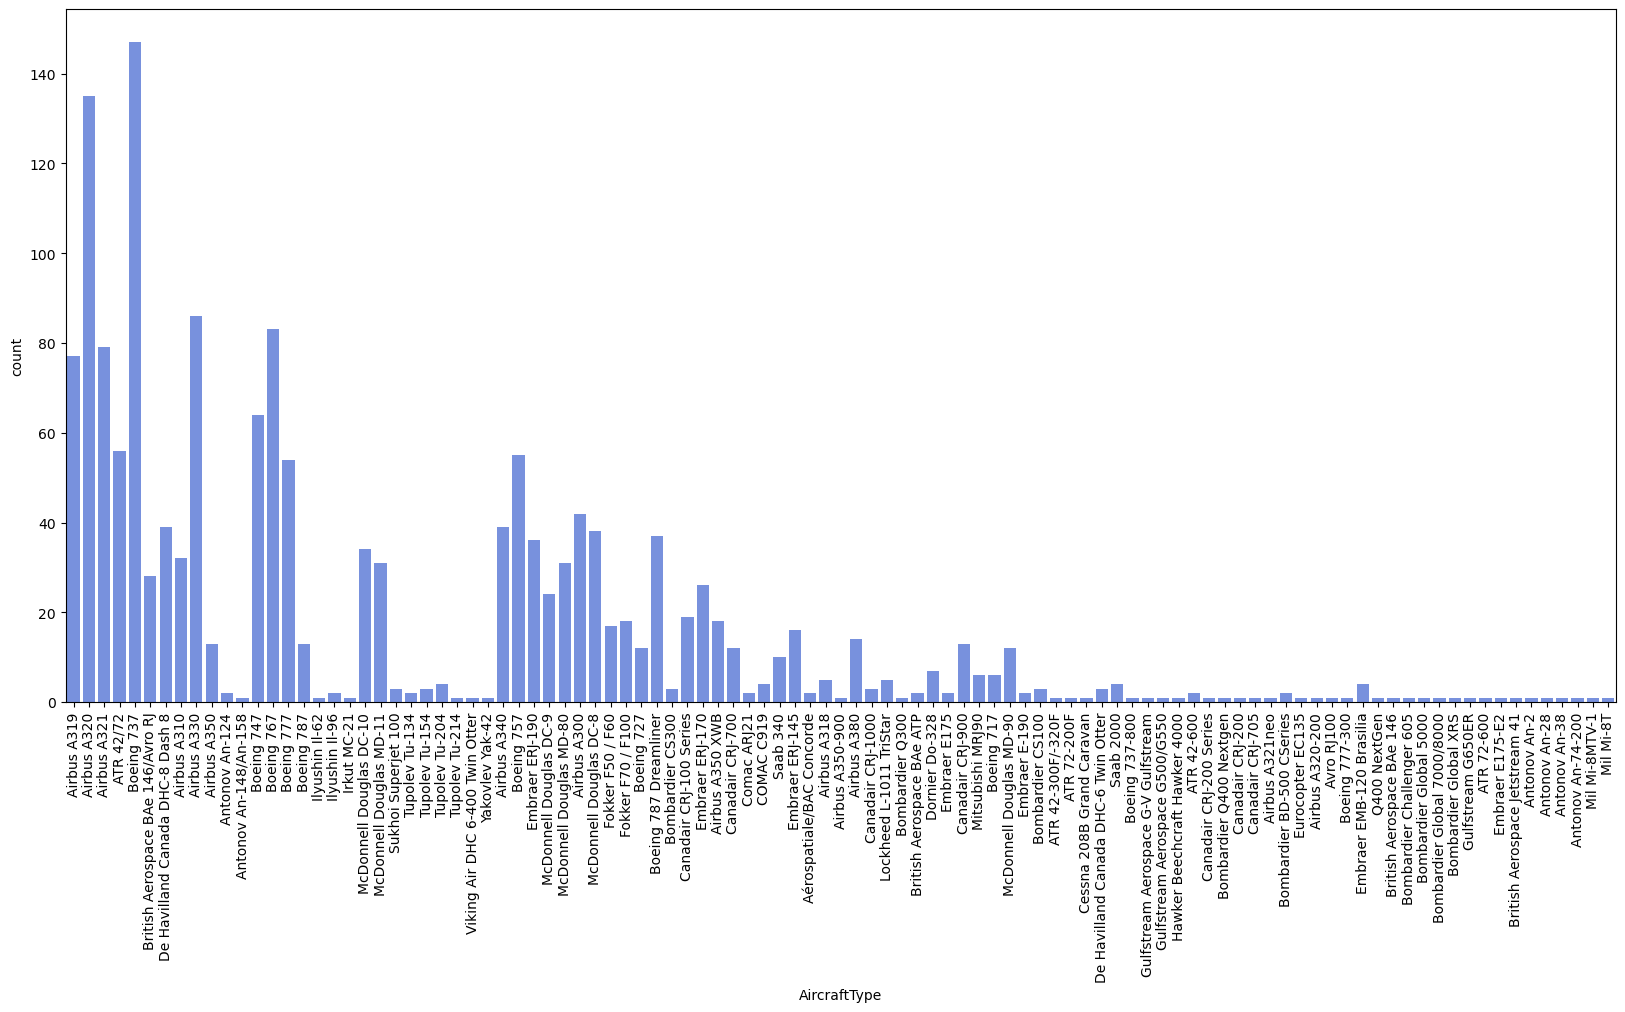

In [103]:
plt.figure(figsize=(20,9))
sb.countplot(x=df.AircraftType)
plt.xticks(rotation=90)
plt.show()
sb.set_palette("coolwarm")

## Fleet Size Trends: Current vs. Future vs. Historic

#### This visual helps us see which airlines are investing in future growth and which are reducing fleet size.

In [106]:
xy=df[['Current','Future','Historic']].corr()

In [107]:
print(xy)

           Current    Future  Historic
Current   1.000000  0.398860  0.398779
Future    0.398860  1.000000  0.127586
Historic  0.398779  0.127586  1.000000


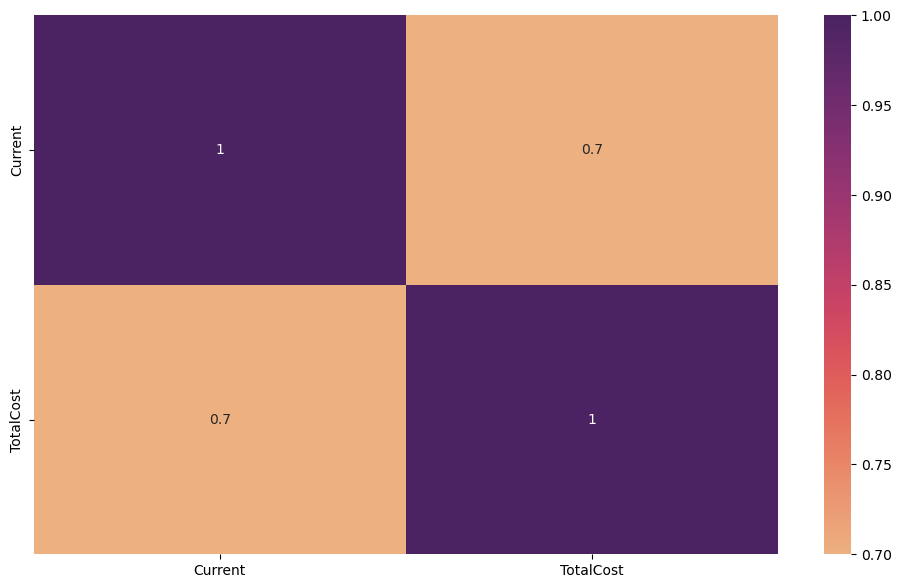

In [224]:
plt.figure(figsize=(12,7))
sb.heatmap(xy,annot=True,cmap='flare')
plt.show()


## Cost Distribution by Airline and Aircraft Type

#### Some aircraft types are consistently expensive across all airlines. Total costs are high for large fleets or costly planes

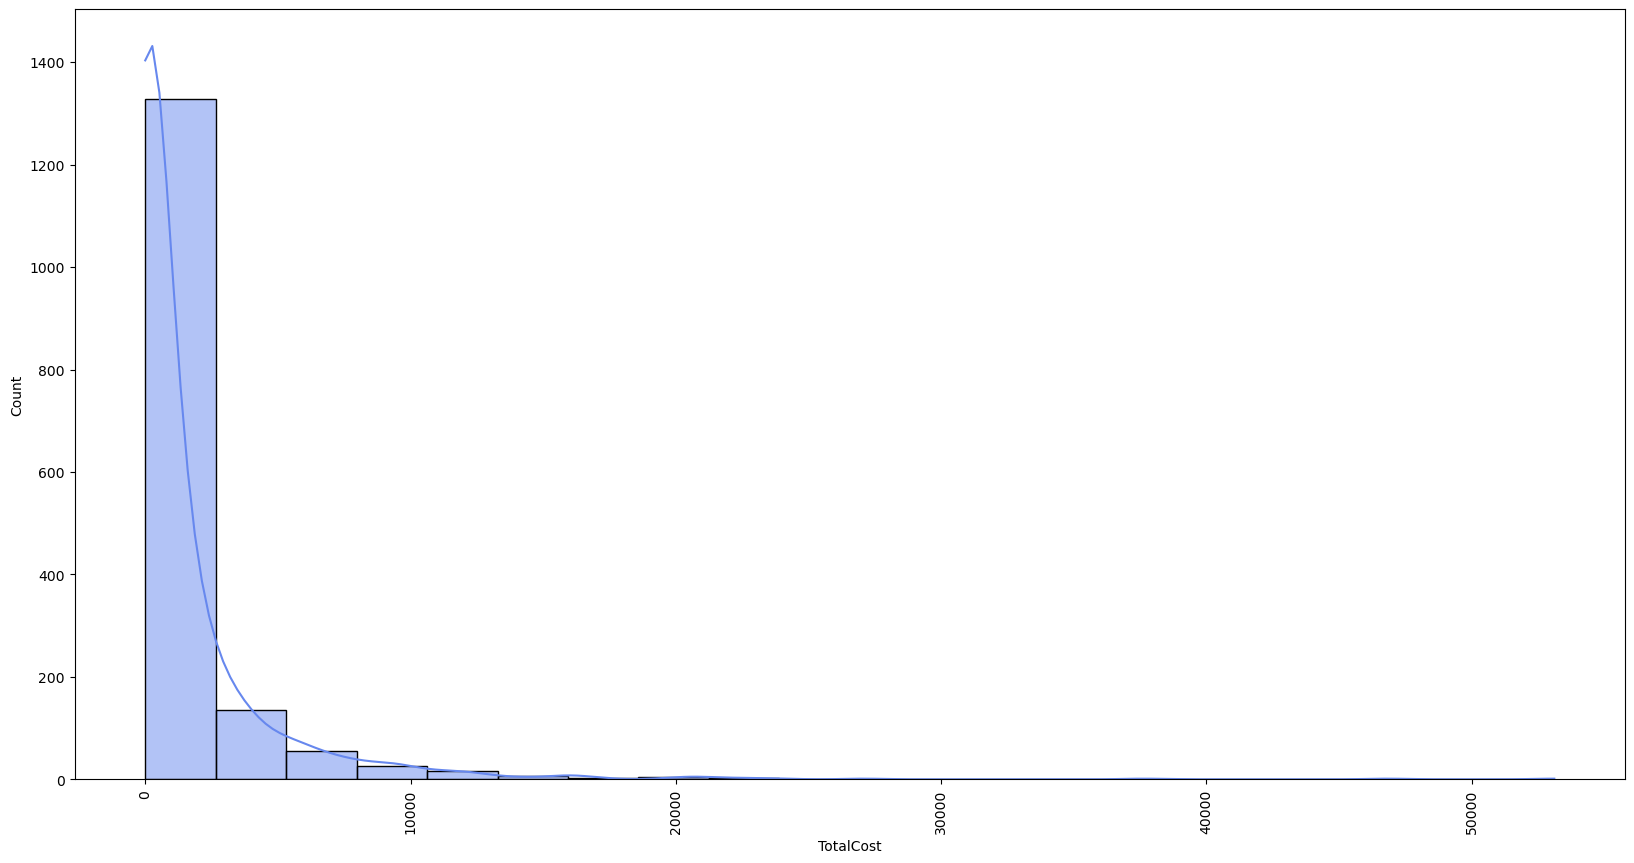

In [111]:
plt.figure(figsize=(20,10))
sb.histplot(x=df.TotalCost,kde=True ,bins=20)
plt.xticks(rotation=90)
plt.show()
sb.set_palette("coolwarm")

## Average Age of Aircraft by Airline and Type

#### Newer fleets are typically found in airlines that are upgrading their operations. Older fleets may mean higher maintenance costs.

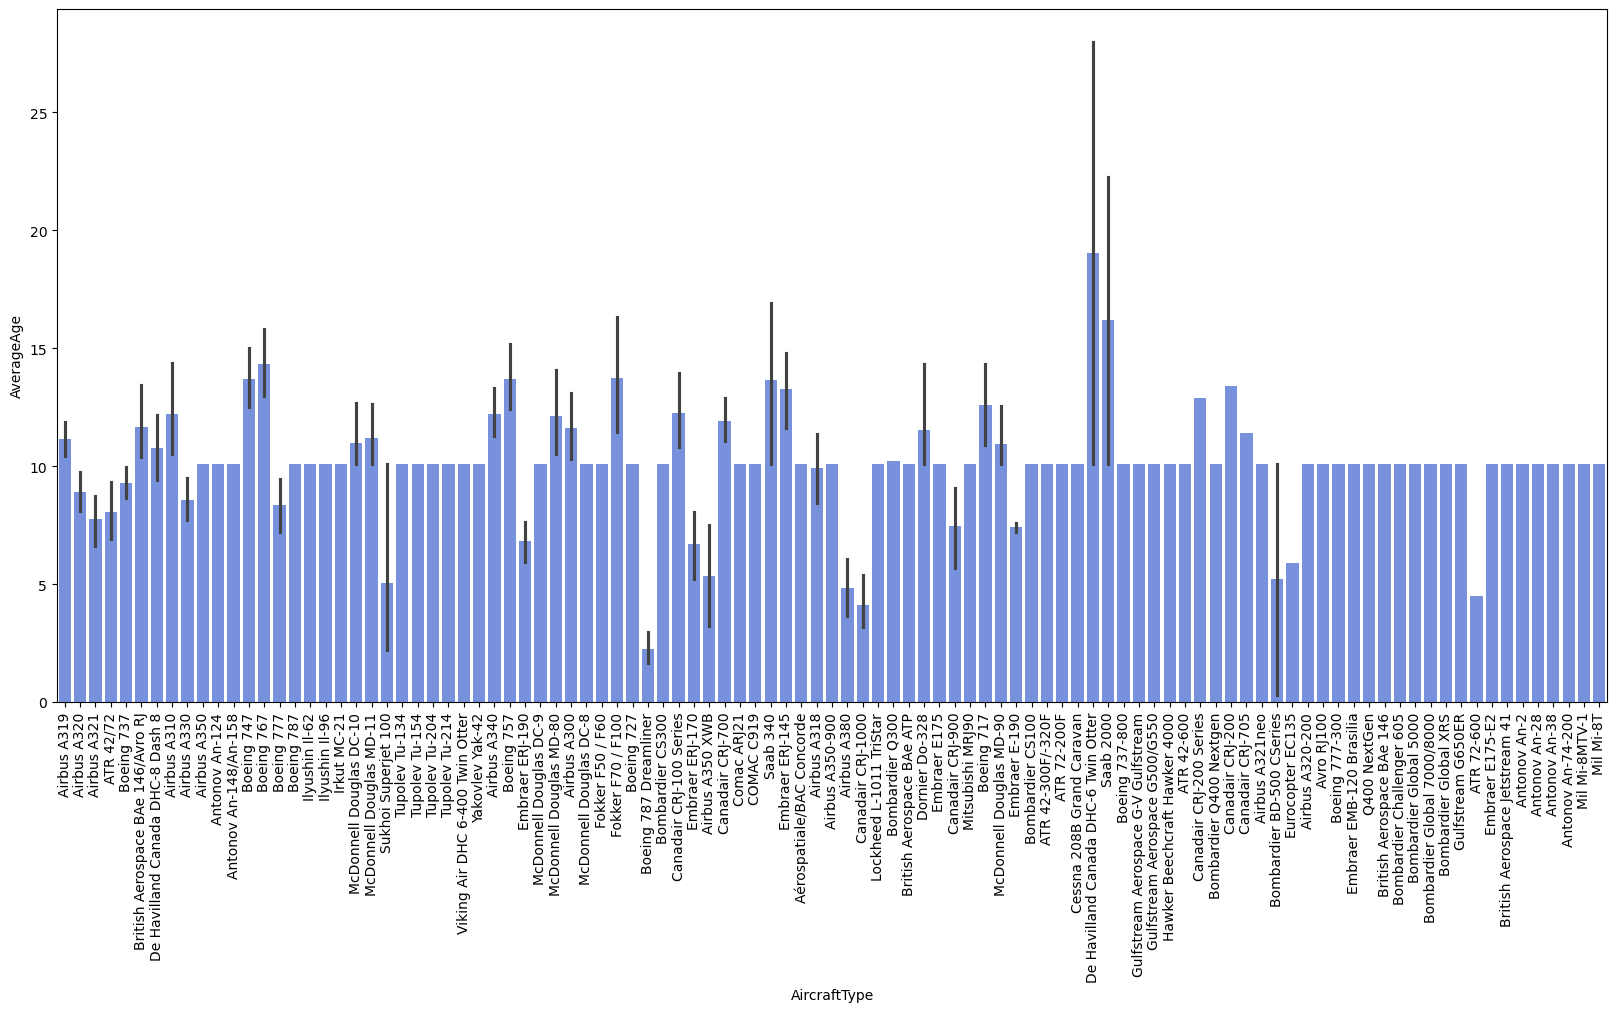

In [114]:
plt.figure(figsize=(20,9))
sb.barplot(x=df.AircraftType,y=df.AverageAge)
plt.xticks(rotation=90)
plt.show()

sb.set_palette("coolwarm")

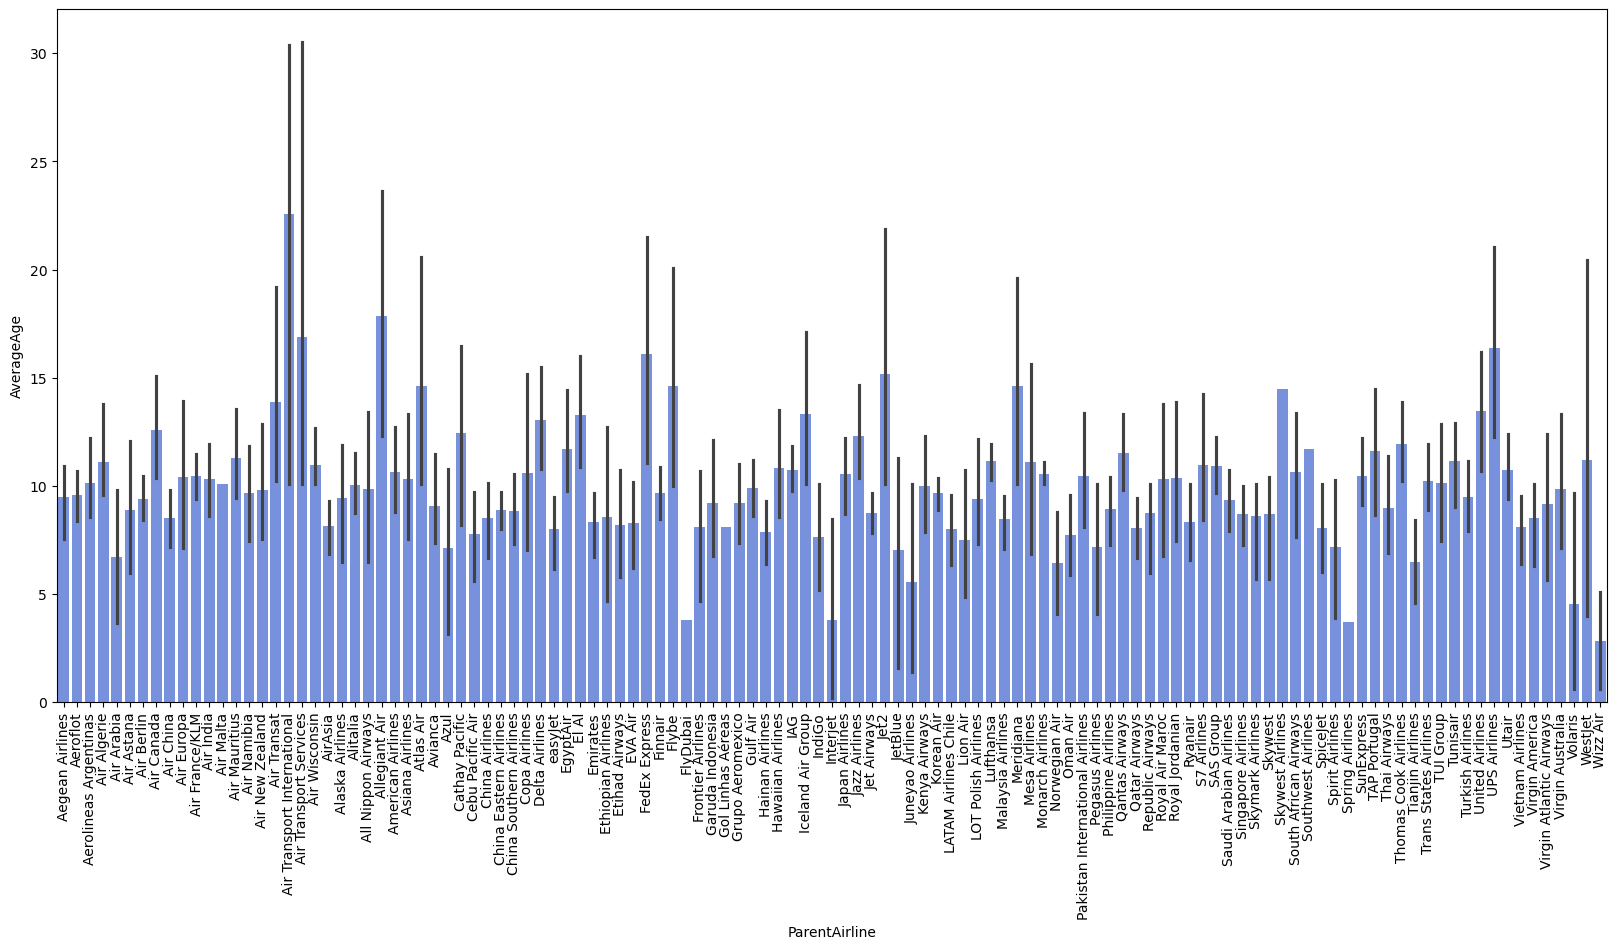

In [115]:
plt.figure(figsize=(20,9))
sb.barplot(x=df.ParentAirline,y=df.AverageAge)
plt.xticks(rotation=90)
plt.show()
sb.set_palette("coolwarm")

## Relationship: Average Age vs Total Cost

#### Airlines with older fleets usually have lower purchase costs, but the long-term cost may be higher due to inefficiency.



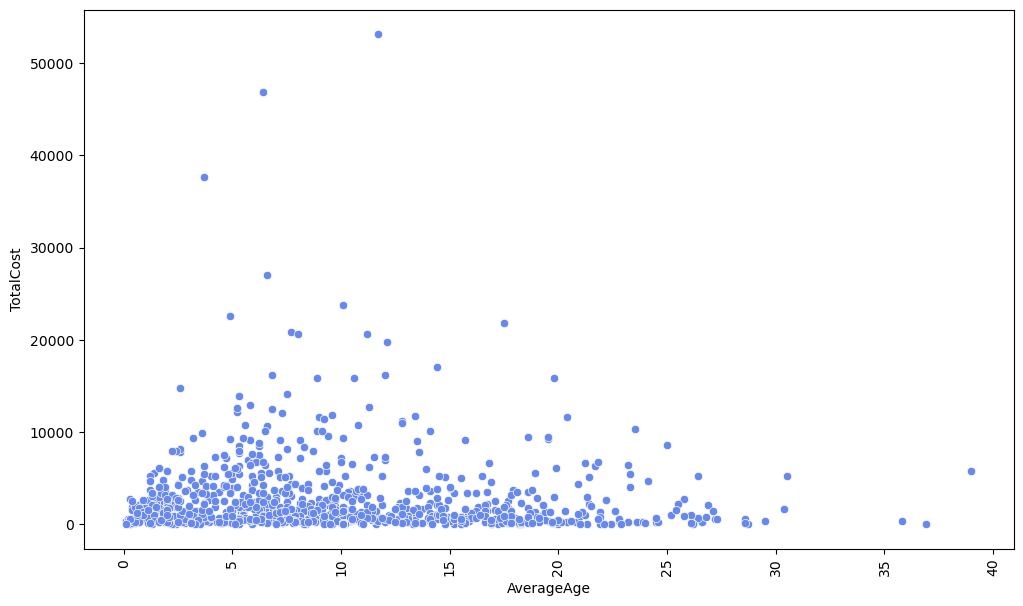

In [118]:
plt.figure(figsize=(12,7))
sb.scatterplot(x=df.AverageAge,y=df.TotalCost)
plt.xticks(rotation=90)
plt.show()
sb.set_palette("coolwarm")

# 3. Cost Analysis

## Top Airlines by Total Fleet Cost

#### A few airlines hold the majority of the total fleet cost, either due to size or having more expensive aircraft.

In [122]:
fleet_cost_summary = df.groupby('ParentAirline')['TotalCost'].sum()

In [123]:
sorted_fleet_cost =fleet_cost_summary.sort_values(ascending=False)

In [124]:
print("Parent Airlines with the highest total fleet cost:")
print(sorted_fleet_cost.head())

Parent Airlines with the highest total fleet cost:
ParentAirline
American Airlines    121013.0
Lufthansa             95741.0
United Airlines       90037.0
IAG                   88814.0
Emirates              85191.0
Name: TotalCost, dtype: float64


## Unit Cost Comparison by Airline and Aircraft Type

#### Some airlines focus on premium aircraft with high unit costs, while others prefer budget-friendly aircraft.

In [127]:
unit_cost_comparison = df.groupby(['ParentAirline', 'AircraftType'])['UnitCost'].mean()

In [128]:
sorted_unit_cost_comparison = unit_cost_comparison.sort_values(ascending=False)

In [129]:
print("Comparison of Unit Costs across Parent Airlines and Aircraft Types:")
print(sorted_unit_cost_comparison)

Comparison of Unit Costs across Parent Airlines and Aircraft Types:
ParentAirline            AircraftType             
Etihad Airways           Airbus A380                  433.0
IAG                      Airbus A380                  433.0
Emirates                 Airbus A380                  433.0
China Southern Airlines  Airbus A380                  433.0
Malaysia Airlines        Airbus A380                  433.0
                                                      ...  
FedEx Express            Boeing 727                     4.0
Utair                    Antonov An-28                  3.0
FedEx Express            Cessna 208B Grand Caravan      3.0
Utair                    Antonov An-38                  2.0
                         Antonov An-2                   2.0
Name: UnitCost, Length: 1228, dtype: float64


## Future Aircraft Orders and Associated Costs by Airline

#### We can see which airlines are heavily investing in the future. High future order costs show aggressive expansion plans.

In [132]:
future_order_costs = df.groupby('ParentAirline')['Orders'].sum()

In [133]:
sorted_future_order_costs = future_order_costs.sort_values(ascending=False)

In [134]:
print("Total Costs of Future Orders by Parent Airlines:")
print(sorted_future_order_costs)

Total Costs of Future Orders by Parent Airlines:
ParentAirline
Lufthansa            2242.21
IAG                  1505.14
Air France/KLM       1491.78
American Airlines    1019.30
Avianca               994.71
                      ...   
Spring Airlines        63.00
Interjet               58.00
Juneyao Airlines       49.82
Air Malta              48.82
Skywest Airlines       24.41
Name: Orders, Length: 117, dtype: float64


# 4. Correlation and Anomaly Detection

## Correlation Scatterplot: Orders, Age, Fleet Size, and Cost

### More orders usually mean higher total cost, which makes sense. But some airlines spend a lot without placing many orders—this needs further investigation.
#### 1.Positive correlation between orders and total cost – more orders → higher investment.


In [138]:
correlation = df['TotalCost'].corr(df['Orders'])
print(f"Correlation between Total Cost and Number of Orders: {correlation}")

Correlation between Total Cost and Number of Orders: 0.3964060083051909


In [139]:
xy=df[['TotalCost','Orders']].corr()

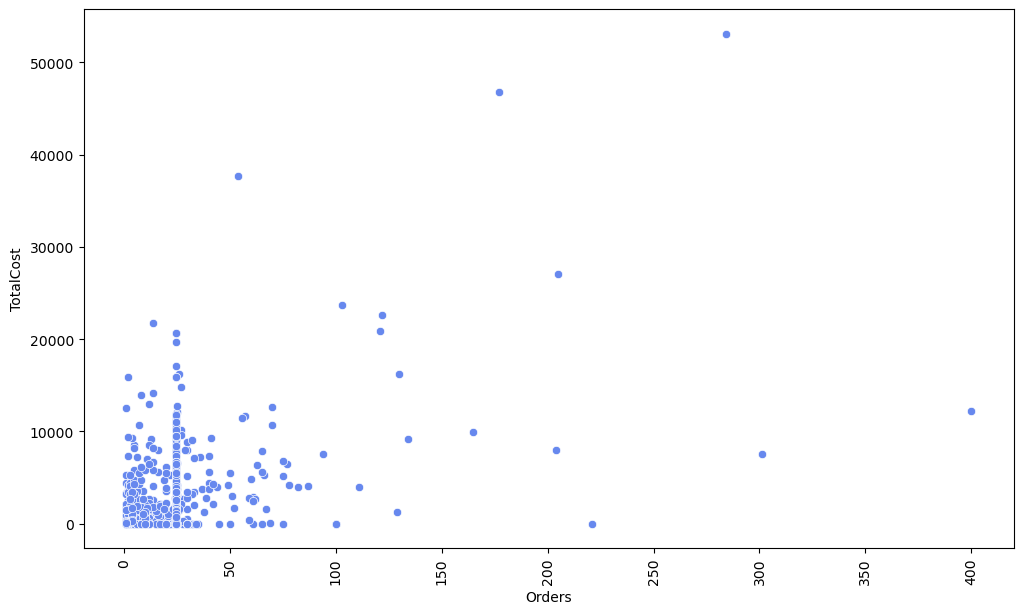

In [141]:
plt.figure(figsize=(12,7))
sb.scatterplot(x=df.Orders,y=df.TotalCost)
plt.xticks(rotation=90)
plt.show()
sb.set_palette("coolwarm")

#### 2.Average age sometimes correlates with total cost (older fleets can be more expensive to maintain).

In [143]:
correlation_age_cost = df['AverageAge'].corr(df['TotalCost'])
print(f"Correlation between Average Age and Total Cost: {correlation_age_cost}")

Correlation between Average Age and Total Cost: -0.06656894503597573


In [144]:
xy=df[['AverageAge','TotalCost']].corr()

In [145]:
xy

,AverageAge,TotalCost
AverageAge,1.000000,-0.066569
TotalCost,-0.066569,1.000000


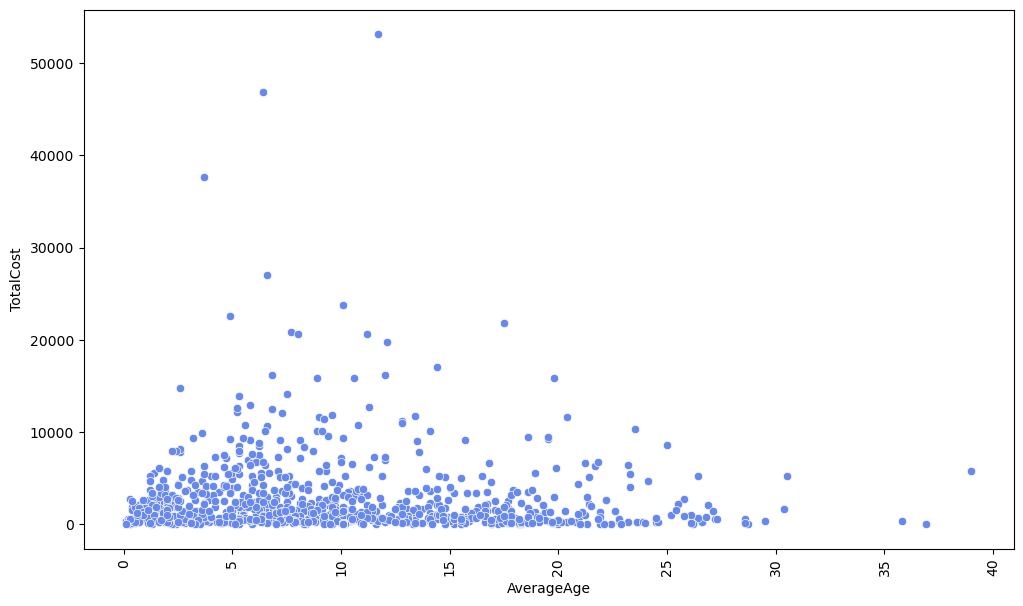

In [146]:
plt.figure(figsize=(12,7))
sb.scatterplot(x=df.AverageAge,y=df.TotalCost)
plt.xticks(rotation=90)
plt.show()
sb.set_palette("coolwarm")

#### 3.Current fleet size generally aligns with total cost due to volume.

In [148]:
correlation_fleet_cost = df['Current'].corr(df['TotalCost'])
print(f"Correlation between Current Fleet Size and Total Cost: {correlation_fleet_cost}")

Correlation between Current Fleet Size and Total Cost: 0.6999337485577889


In [149]:
xy=df[['Current','TotalCost']].corr()

In [150]:
xy

,Current,TotalCost
Current,1.000000,0.699934
TotalCost,0.699934,1.000000


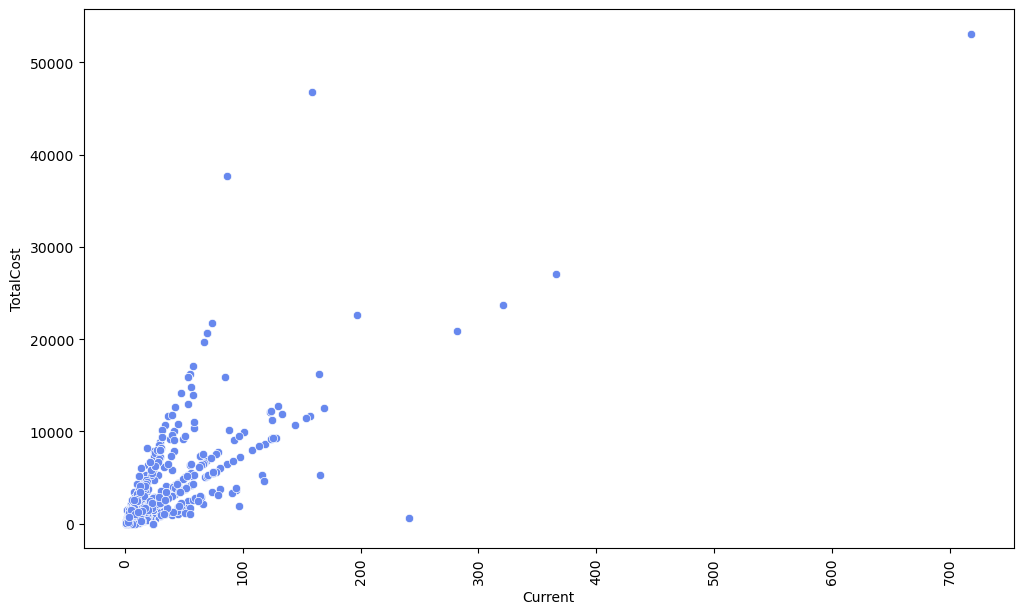

In [151]:
plt.figure(figsize=(12,7))
sb.scatterplot(x=df.Current,y=df.TotalCost)
plt.xticks(rotation=90)
plt.show()
sb.set_palette("coolwarm")

## Outliers in Unit Cost

#### Some aircraft types or airlines show very unusual costs or fleet ages. These outliers might be due to special use cases or data errors.

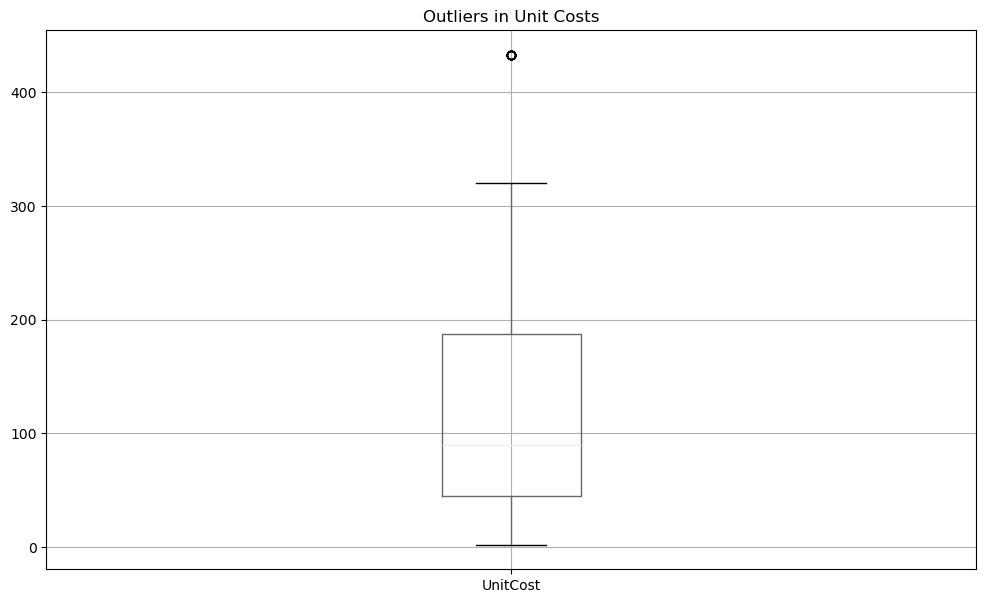

In [154]:
plt.figure(figsize=(12,7))
df.boxplot(column='UnitCost') 
plt.title('Outliers in Unit Costs')
plt.show()

## Outliers in  Aircraft Average Age

#### A few aircraft types have much older average ages compared to the rest of the fleet. These planes might be kept for specific routes or due to budget constraints. Older aircraft may lead to more frequent maintenance issues and lower fuel efficiency, which can affect operational performance over time.

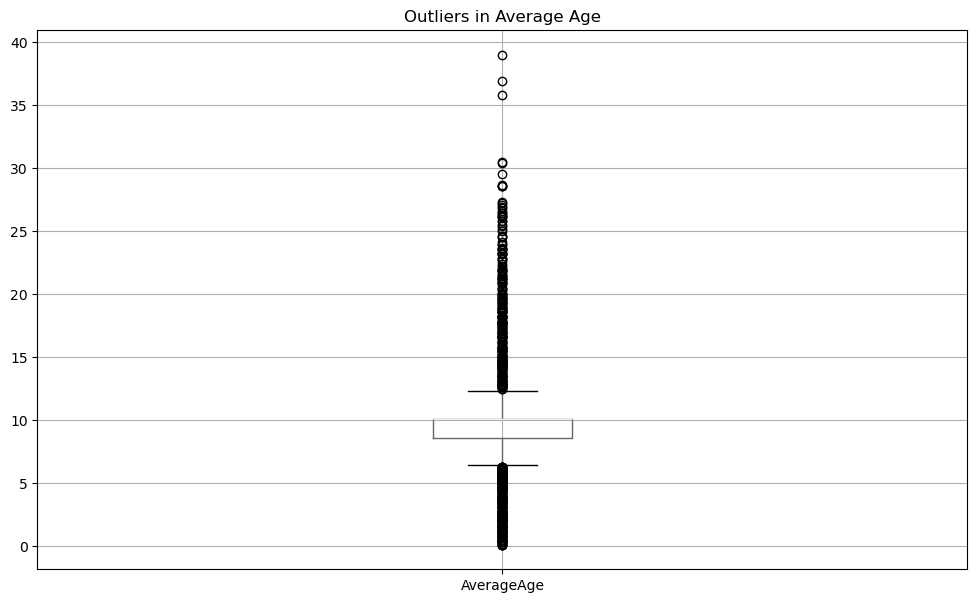

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

In [162]:
plt.figure(figsize=(12,7))
df.boxplot(column='AverageAge') 
plt.title('Outliers in Average Age')
plt.show()
plt.tight_layout

In [163]:
unit_cost_outliers = df[df['UnitCost'] > df['UnitCost'].quantile(0.95)]
print("Outliers in Unit Costs:")
print(unit_cost_outliers[['AircraftType', 'ParentAirline', 'UnitCost']])

Outliers in Unit Costs:
     AircraftType            ParentAirline  UnitCost
26     Boeing 747                 Aeroflot     316.0
54     Boeing 747    Aerolineas Argentinas     316.0
67     Boeing 747              Air Algerie     316.0
110    Boeing 747               Air Canada     316.0
141    Boeing 747                Air China     316.0
...           ...                      ...       ...
1418   Boeing 747     Thomas Cook Airlines     316.0
1476   Boeing 747                 Tunisair     316.0
1504   Boeing 747          United Airlines     316.0
1513   Boeing 747             UPS Airlines     316.0
1558   Boeing 747  Virgin Atlantic Airways     316.0

[77 rows x 3 columns]


In [164]:
unit_cost_outliers = df[df['AverageAge'] > df['AverageAge'].quantile(0.95)]
print("Outliers in AverageAge:")
print(unit_cost_outliers[['AircraftType', 'ParentAirline', 'AverageAge']])

Outliers in AverageAge:
                 AircraftType     ParentAirline  AverageAge
68                 Boeing 767       Air Algerie        26.3
101               Airbus A320        Air Canada        23.3
111                Boeing 767        Air Canada        25.8
145                Boeing 757         Air China        20.4
159                 ATR 42/72        Air Europa        21.9
...                       ...               ...         ...
1504               Boeing 747   United Airlines        21.2
1514               Boeing 757      UPS Airlines        23.3
1517  McDonnell Douglas MD-11      UPS Airlines        23.2
1573        Fokker F70 / F100  Virgin Australia        24.6
1579               Boeing 767           WestJet        24.5

[79 rows x 3 columns]


In [166]:
print(df.AircraftType.unique())
p=input('Enter AircraftType')
a=df[df.AircraftType==p]
a

['Airbus A319' 'Airbus A320' 'Airbus A321' 'ATR 42/72' 'Boeing 737'
 'British Aerospace BAe 146/Avro RJ' 'De Havilland Canada DHC-8 Dash 8'
 'Airbus A310' 'Airbus A330' 'Airbus A350' 'Antonov An-124'
 'Antonov An-148/An-158' 'Boeing 747' 'Boeing 767' 'Boeing 777'
 'Boeing 787' 'Ilyushin Il-62' 'Ilyushin Il-96' 'Irkut MC-21'
 'McDonnell Douglas DC-10' 'McDonnell Douglas MD-11' 'Sukhoi Superjet 100'
 'Tupolev Tu-134' 'Tupolev Tu-154' 'Tupolev Tu-204' 'Tupolev Tu-214'
 'Viking Air DHC 6-400 Twin Otter' 'Yakovlev Yak-42' 'Airbus A340'
 'Boeing 757' 'Embraer ERJ-190' 'McDonnell Douglas DC-9'
 'McDonnell Douglas MD-80' 'Airbus A300' 'McDonnell Douglas DC-8'
 'Fokker F50 / F60' 'Fokker F70 / F100' 'Boeing 727'
 'Boeing 787 Dreamliner' 'Bombardier CS300' 'Canadair CRJ-100 Series'
 'Embraer ERJ-170' 'Airbus A350 XWB' 'Canadair CRJ-700' 'Comac ARJ21'
 'COMAC C919' 'Saab 340' 'Embraer ERJ-145' 'Aérospatiale/BAC Concorde'
 'Airbus A318' 'Airbus A350-900' 'Airbus A380' 'Canadair CRJ-1000'
 'Lockhee

Enter AircraftType Mil Mi-8T


,ParentAirline,Airline,AircraftType,Current,Future,Historic,Total,Orders,UnitCost,TotalCost,AverageAge
1529,Utair,Vostok Aviation Company,Mil Mi-8T,6.0,3.38,14.51,24.95,24.41,117.8,0.0,10.11


## Fleet Size Consistency: Current vs Historic vs Future

#### Large differences between past, current, and future fleets show major shifts—like retiring old fleets or making large future investments.

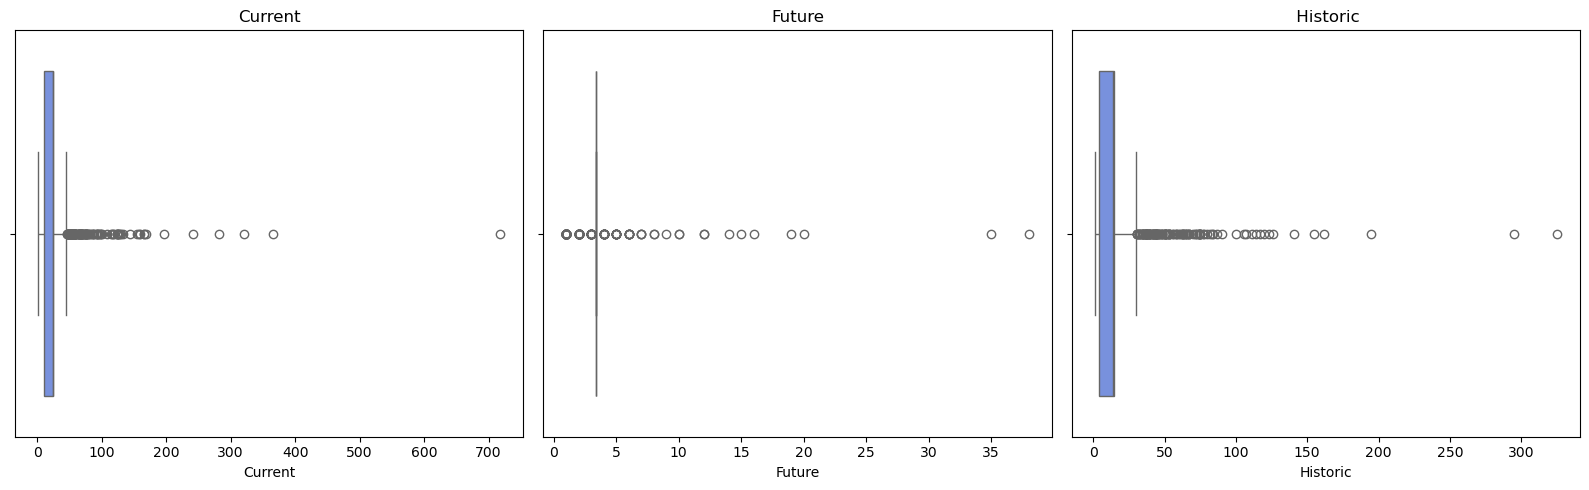

In [226]:
plt.figure(figsize=(16, 5))
sb.set_palette('coolwarm')

# Current

plt.subplot(1, 3, 1)

sb.boxplot(data=df, x='Current')
plt.title('Current')
plt.xlabel('Current')

# Future

plt.subplot(1, 3, 2)
sb.boxplot(data=df, x='Future')
plt.title('Future')
plt.xlabel('Future')



# Historic

plt.subplot(1, 3, 3)
sb.boxplot(data=df, x='Historic')
plt.title(' Historic')
plt.xlabel('Historic')

plt.tight_layout()

plt.show()